# IY021 – SVM vs Catch22+SVM on ALL Experimental Time Series

**Goal:** Same analysis as `IY021_catch22_svm_exp_data.ipynb` but including all experiments with
clear carbon-source labels from `EXP-25-IY013/transformed_exp_time_series_data/`.

**Environments (labels) — verified via `get_exp_summary`:**
- `0` — 2% glucose (experiments 19316, 18589, 19330)
- `1` — 0.1% glucose (experiments 19566, 18446, 19394)
- `2` — 0.01% glucose (experiments 19554, 20213)
- `3` — 2% galactose (experiment 19391 — pump: 2% raffinose -> 2% galactose)
- `4` — 0.01% galactose (experiment 19392 — pump: 2% glucose -> 0.01% galactose)

**Excluded experiments:**
- `18360` — no explicit carbon source concentration in filename ("2min" refers to interval)
- `18464` — mock condition (not a carbon source concentration)

**Length handling:** Different experiments have different numbers of timepoints.
- Raw SVM: all series truncated to the global minimum timepoints across loaded files
- Catch22 + SVM: features extracted from full-length series (Catch22 is length-agnostic)

**Data source:** `EXP-25-IY013/transformed_exp_time_series_data/`

In [6]:
import glob
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pycatch22
from pathlib import Path
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from tqdm import tqdm

np.random.seed(42)
sys.path.insert(0, "/home/ianyang/wela/src")
sys.path.insert(0, "/home/ianyang/alibylite/src")
DATA_DIR = Path("/home/ianyang/stochastic_simulations/experiments/EXP-25-IY013/transformed_exp_time_series_data")

## 1. Load Data & Assign Environment Labels

In [7]:
# Verify experimental conditions using get_exp_summary
import glob as _glob
from wela.get_exp_conditions import get_exp_summary

_BASE = "/home/ianyang/alibylite/high_quality_data_analysis"
_EXPERIMENT_OMIDS = {
    "19316": "19316_2020_10_26_steadystate_glucose_144m_2w2_00",
    "18589": "18589_2020_02_10_steadystate_glucose_898S_2w2_01",
    "19330": "19330_2020_11_02_steadystate_glucose_1345m_2w2_00",
    "19566": "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01",
    "18446": "18446_2020_01_08_steadystate_glucose_2w0p1_2min_01",
    "19394": "19394_2020_11_12_steadystate_glucose_1345m_2w0p1_00",
    "19554": "19554_2020_12_06_steadystate_glucose_2w0p01_900m_00",
    "20213": "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00",
    "19391": "19391_2020_11_12_steadystate_glucose_1345m_2w0p01_00",
    "19392": "19392_2020_11_12_steadystate_glucose_898m_2w0p01_00",
}

print("Experimental condition verification via get_exp_summary")
print("=" * 70)
for prefix, omid in _EXPERIMENT_OMIDS.items():
    acq = _glob.glob(f"{_BASE}/{omid}/*Acq.txt")[0]
    log = _glob.glob(f"{_BASE}/{omid}/*log.txt")[0]
    summary_df, tf_df, _ = get_exp_summary(acq, log)
    pump_contents = summary_df["pump_contents"].values[0]
    omero_tags    = summary_df["omero_tags"].values[0]
    switch_times  = summary_df["switch_times"].values[0]
    print(f"\n{prefix}  ({omid[:60]})")
    print(f"  Pump contents : {pump_contents}")
    print(f"  Switch times  : {switch_times}  (steady-state condition = pump 2)")
    print(f"  OMERO tags    : {omero_tags}")

print("\n")
print("Label assignments (from acquisition file pump contents):")
print("  19316, 18589, 19330  -> label 0 : 2% glucose      (both pumps = 2% glucose)     OK")
print("  19566, 18446, 19394  -> label 1 : 0.1% glucose    (pump 2 = 0.1% glucose)       OK")
print("  19554, 20213         -> label 2 : 0.01% glucose   (pump 2 = 0.01% glucose)      OK")
print("  19391                -> label 3 : 2% galactose    (pump 2 = 2% galactose)       OK")
print("  19392                -> label 4 : 0.01% galactose (pump 2 = 0.01% galactose)    OK")
print("  (Note: OMERO tags for 19391 and 19392 incorrectly say '0.01% glucose';")
print("   acquisition file pump contents are used as ground truth.)")

Experimental condition verification via get_exp_summary
=== EXPERIMENT SUMMARY ===

📸 IMAGING SETUP (from acquisition file):
• Channels: ['Brightfield', 'GFP', 'mCherry']
• Exposure times: [30, 30, 100] ms
• Camera EM gain: 270

⏱️ TIME-LAPSE SETTINGS:
• Time interval: 120 seconds (2.0 minutes)
• Number of timepoints: 540
• Total experiment time: 64800 seconds (18.0 hours)

🧪 MICROFLUIDICS SETUP:
• Number of pumps: 2
• Pump rates: [[0.0], [4.0]]
• Pump contents: ['2% glucose in SC', '2% glucose in SC']
• Number of switches: 1
• Switch volumes: 50
• Switch rates: 100
• Switch times: [180]

🔬 MICROSCOPE SETUP (from log file):
• Microscope: Batgirl
• Date: 2020-10-25 00:00:00
• Experiment start time: 2020-10-25 17:09:13
• Capture of the first image: 2020-10-25 17:09:14
• MultiDGUI commit: 29bfe736500ed3f8be9c19585bee78cc67ceae26
• Experimental details: Aim:   Strain:   Comments:   Strains 1344 and 1346 were both labelled 1346 in the subculturing so not sure which is which.

💾 OMERO INFORM

In [8]:
# Map experiment ID prefix to carbon-source environment label
# Verified via get_exp_summary (see cell above) — labels based on pump 2 (steady-state condition):
#   19391: pump = ['2% raffinose in SC', '2% galactose in SC']  -> 2% galactose
#   19392: pump = ['2% glucose in SC', '0.01% galactose in SC'] -> 0.01% galactose
#   (OMERO tags for 19391 and 19392 incorrectly say '0.01% glucose')
EXPERIMENT_LABELS = {
    # 2% glucose (both pumps = 2% glucose in SC)
    "19316": (0, "2% glucose"),
    "18589": (0, "2% glucose"),
    "19330": (0, "2% glucose"),
    # 0.1% glucose (pump 2 = 0.1% glucose in SC)
    "19566": (1, "0.1% glucose"),
    "18446": (1, "0.1% glucose"),
    "19394": (1, "0.1% glucose"),
    # 0.01% glucose (pump 2 = 0.01% glucose in SC)
    "19554": (2, "0.01% glucose"),
    "20213": (2, "0.01% glucose"),
    # 2% galactose (pump 1 = 2% raffinose, pump 2 = 2% galactose in SC)
    "19391": (3, "2% galactose"),
    # 0.01% galactose (pump 1 = 2% glucose, pump 2 = 0.01% galactose in SC)
    "19392": (4, "0.01% galactose"),
}

META_COLS = ["id", "group", "experiment"]
label_names = {
    0: "2% glucose",
    1: "0.1% glucose",
    2: "0.01% glucose",
    3: "2% galactose",
    4: "0.01% galactose",
}

all_ts_raw = []   # list of (n_cells, n_timepoints) arrays — variable T per file
all_y = []

csv_files = sorted(DATA_DIR.glob("*.csv"))
for csv_path in csv_files:
    exp_prefix = csv_path.name.split("_")[0]
    if exp_prefix not in EXPERIMENT_LABELS:
        print(f"Skipping (no label):     {csv_path.name[:70]}")
        continue

    # Skip the 19316 _mCherry_mCherry file (same cells as _mCherry, different recording window)
    if "_mCherry_mCherry_" in csv_path.name:
        print(f"Skipping (duplicate):    {csv_path.name[:70]}")
        continue

    label, env_name = EXPERIMENT_LABELS[exp_prefix]
    df = pd.read_csv(csv_path)

    time_cols = [c for c in df.columns if c not in META_COLS]
    ts_matrix = df[time_cols].values.astype(float)  # (n_cells, n_timepoints)

    all_ts_raw.append(ts_matrix)
    all_y.extend([label] * len(ts_matrix))
    print(f"  {csv_path.name[:65]}")
    print(f"    -> label={label} ({env_name}), {ts_matrix.shape[0]} cells x {ts_matrix.shape[1]} timepoints")

# Determine common (minimum) number of timepoints
min_T = min(ts.shape[1] for ts in all_ts_raw)
print(f"\nTimepoints per file: {[ts.shape[1] for ts in all_ts_raw]}")
print(f"Global minimum: {min_T} timepoints -- all series will be truncated to this length for Raw SVM")

# Truncated dataset (for Raw SVM)
X_raw = np.vstack([ts[:, :min_T] for ts in all_ts_raw])  # (N, min_T)
y     = np.array(all_y, dtype=int)

print(f"\nFull dataset: {X_raw.shape[0]} cells x {X_raw.shape[1]} timepoints")
for lbl, name in label_names.items():
    print(f"  Label {lbl} ({name}): {np.sum(y == lbl)} samples")

Skipping (no label):     18360_2020_01_04_steadystate_glucose_2min_01_group_1106_mCherry_time_s
Skipping (no label):     18360_2020_01_04_steadystate_glucose_2min_01_group_898_mCherry_time_se
Skipping (no label):     18360_2020_01_04_steadystate_glucose_2min_01_group_900_mCherry_time_se


  18446_2020_01_08_steadystate_glucose_2w0p1_2min_01_group_po_mCher
    -> label=1 (0.1% glucose), 744 cells x 160 timepoints
Skipping (no label):     18464_2020_01_20_steadystate_glucose_756S_2min_mock_00_group_756_mCher
Skipping (no label):     18464_2020_01_20_steadystate_glucose_756S_2min_mock_00_group_764_mCher
Skipping (no label):     18464_2020_01_20_steadystate_glucose_756S_2min_mock_00_group_903_mCher
  18589_2020_02_10_steadystate_glucose_898S_2w2_01_group_1106_mCher
    -> label=0 (2% glucose), 197 cells x 120 timepoints
  18589_2020_02_10_steadystate_glucose_898S_2w2_01_group_898_mCherr
    -> label=0 (2% glucose), 245 cells x 131 timepoints
  18589_2020_02_10_steadystate_glucose_898S_2w2_01_group_900_mCherr
    -> label=0 (2% glucose), 195 cells x 159 timepoints
Skipping (duplicate):    19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1344_6_mCherry_
  19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1344_6_mCh
    -> label=0 (2% glucose), 71 cells x 94 timepoi

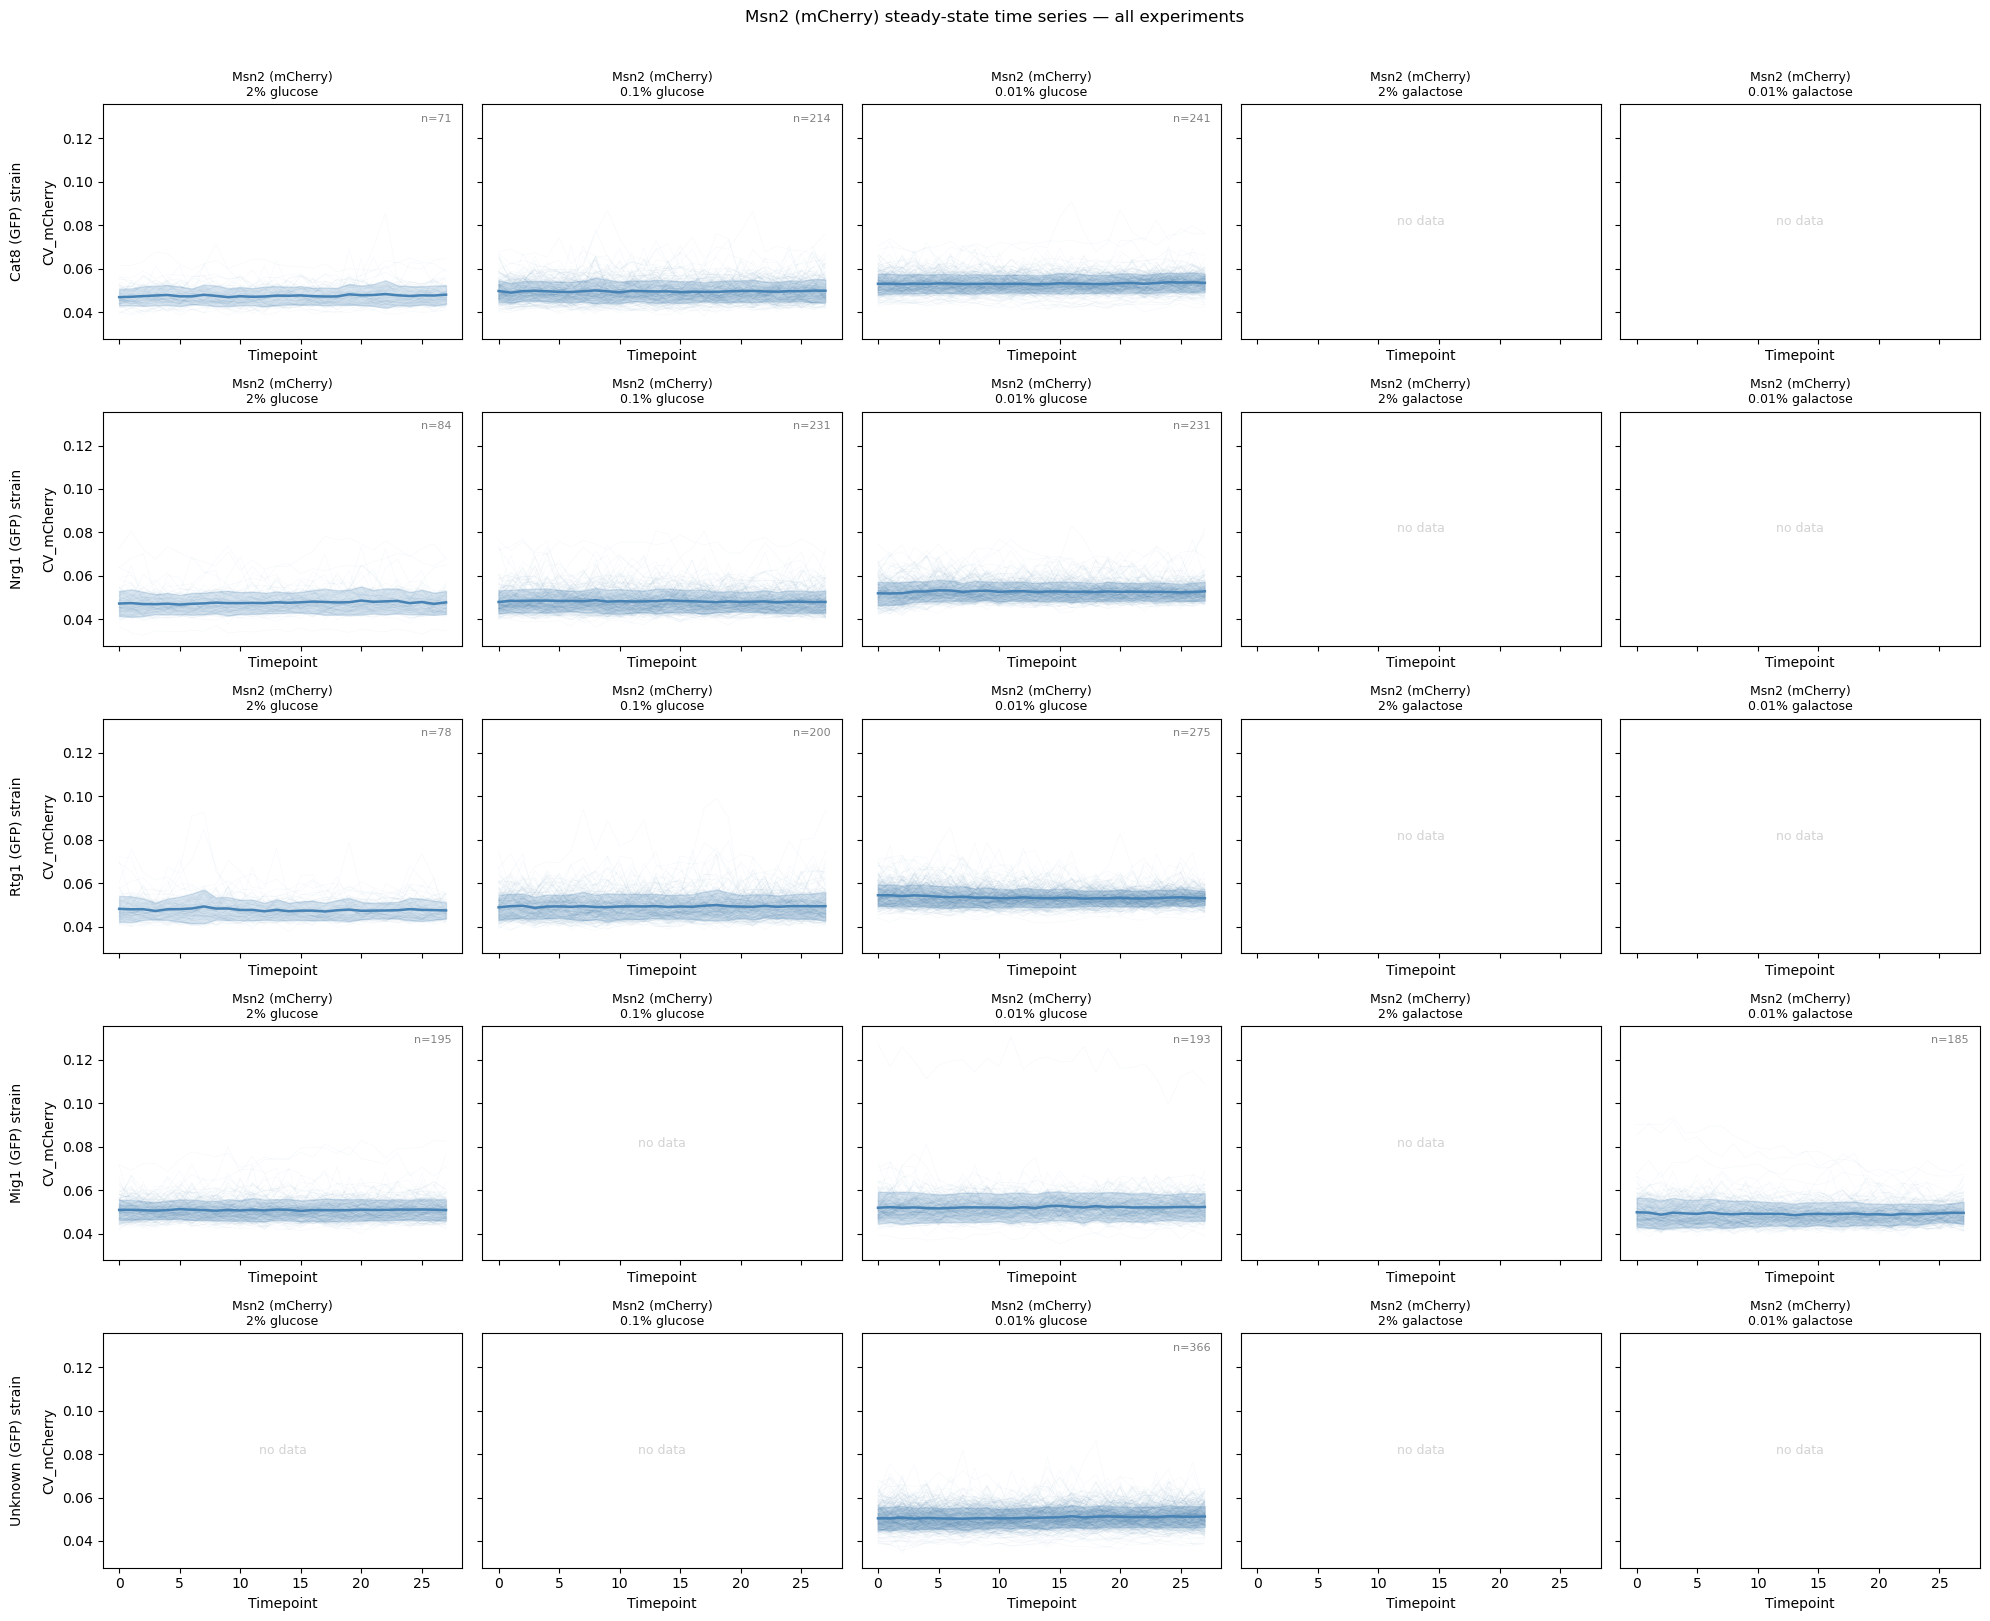

In [9]:

import re as _re

# Group number → GFP TF identity (from OMERO metadata verified above)
GROUP_TO_TF = {
    "1344": "Cat8", "1344_6": "Cat8",
    "1346": "Nrg1", "1346_4": "Nrg1",
    "1347": "Rtg1",
    "900":  "Mig1",
    "756":  "Unknown", "903": "Unknown",
}

# Re-scan CSVs with the same filter logic as the loading cell, but track TF per cell
_plot_X, _plot_y, _plot_tf = [], [], []

for csv_path in sorted(DATA_DIR.glob("*.csv")):
    exp_prefix = csv_path.name.split("_")[0]
    if exp_prefix not in EXPERIMENT_LABELS:
        continue
    if "_mCherry_mCherry_" in csv_path.name:
        continue
    label, _ = EXPERIMENT_LABELS[exp_prefix]
    df = pd.read_csv(csv_path)
    time_cols = [c for c in df.columns if c not in META_COLS]
    ts = df[time_cols].values.astype(float)[:, :min_T]   # truncate to same min_T as X_raw

    m = _re.search(r"_group_(.+?)_mCherry_", csv_path.name)
    group_str = m.group(1) if m else "?"
    tf_name = GROUP_TO_TF.get(group_str, f"group_{group_str}")

    _plot_X.append(ts)
    _plot_y.extend([label] * len(ts))
    _plot_tf.extend([tf_name] * len(ts))

_plot_X  = np.vstack(_plot_X)
_plot_y  = np.array(_plot_y)
_plot_tf = np.array(_plot_tf)

# --- Plot: rows = TF (GFP strain), cols = condition ---
tfs_present  = [t for t in ["Cat8", "Nrg1", "Rtg1", "Mig1", "Unknown"] if t in _plot_tf]
conds_present = sorted(set(_plot_y))
t_axis = np.arange(min_T)

fig, axes = plt.subplots(
    len(tfs_present), len(conds_present),
    figsize=(4 * len(conds_present), 3.2 * len(tfs_present)),
    sharey=True, sharex=True,
)
# ensure 2-D indexing even for single row/col
axes = np.array(axes).reshape(len(tfs_present), len(conds_present))

for row, tf in enumerate(tfs_present):
    for col, lbl in enumerate(conds_present):
        ax   = axes[row, col]
        mask = (_plot_tf == tf) & (_plot_y == lbl)
        X_sub = _plot_X[mask]

        if len(X_sub):
            for trace in X_sub:
                ax.plot(t_axis, trace, color="steelblue", alpha=0.05, linewidth=0.5)
            mean = np.nanmean(X_sub, axis=0)
            std  = np.nanstd(X_sub,  axis=0)
            ax.plot(t_axis, mean, color="steelblue", linewidth=1.8)
            ax.fill_between(t_axis, mean - std, mean + std, color="steelblue", alpha=0.2)
            ax.text(0.97, 0.96, f"n={mask.sum()}", transform=ax.transAxes,
                    ha="right", va="top", fontsize=8, color="gray")
        else:
            ax.text(0.5, 0.5, "no data", transform=ax.transAxes,
                    ha="center", va="center", fontsize=9, color="lightgray")

        ax.set_title(f"Msn2 (mCherry)\n{label_names[lbl]}", fontsize=9)
        ax.set_xlabel("Timepoint")
        if col == 0:
            ax.set_ylabel(f"{tf} (GFP) strain\n\nCV_mCherry")

fig.suptitle("Msn2 (mCherry) steady-state time series — all experiments",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 2. Preprocessing: NaN Handling, Balancing & Train/Test Split

In [10]:
def fill_nans(X):
    """Interpolate NaNs per row; fallback to column median."""
    X = X.copy()
    for i in range(X.shape[0]):
        row = pd.Series(X[i])
        row = row.interpolate().ffill().bfill()
        X[i] = row.values
    col_medians = np.nanmedian(X, axis=0)
    nan_mask = np.isnan(X)
    X[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])
    return X

X_clean = fill_nans(X_raw)
print(f"NaN remaining after fill: {np.isnan(X_clean).sum()}")

# --- Balance classes by subsampling to the minority class size ---
min_count = min(np.sum(y == lbl) for lbl in label_names)
print(f"Minority class count: {min_count} → subsampling all classes to this size")

balanced_idx = []
for lbl in sorted(label_names):
    idx = np.where(y == lbl)[0]
    chosen = np.random.choice(idx, size=min_count, replace=False)
    balanced_idx.extend(chosen)

balanced_idx = np.array(balanced_idx)
X_bal = X_clean[balanced_idx]
y_bal = y[balanced_idx]

print(f"\nBalanced dataset: {X_bal.shape[0]} cells × {X_bal.shape[1]} timepoints")
for lbl, name in label_names.items():
    print(f"  Label {lbl} ({name}): {np.sum(y_bal == lbl)}")

# --- Train / Test split (80/20, stratified) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)
print(f"\nTrain: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")
print(f"Train class counts: {np.bincount(y_train)}")
print(f"Test  class counts: {np.bincount(y_test)}")

NaN remaining after fill: 0
Minority class count: 289 → subsampling all classes to this size

Balanced dataset: 1445 cells × 28 timepoints
  Label 0 (2% glucose): 289
  Label 1 (0.1% glucose): 289
  Label 2 (0.01% glucose): 289
  Label 3 (2% galactose): 289
  Label 4 (0.01% galactose): 289

Train: 1156  |  Test: 289
Train class counts: [231 232 231 231 231]
Test  class counts: [58 57 58 58 58]


## 3. Raw SVM (RBF) – Truncated Time Series as Features

In [11]:
print("=== Raw SVM (RBF) ===")
print(f"(using {X_train.shape[1]} timepoints per series)")

svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)),
])

svm_pipe.fit(X_train, y_train)
y_pred_svm = svm_pipe.predict(X_test)
svm_acc = accuracy_score(y_test, y_pred_svm)

print(f"Raw SVM Accuracy: {svm_acc:.4f}")
print()
print(classification_report(y_test, y_pred_svm, target_names=[label_names[i] for i in sorted(label_names)]))

=== Raw SVM (RBF) ===
(using 28 timepoints per series)
Raw SVM Accuracy: 0.4083

                 precision    recall  f1-score   support

     2% glucose       0.38      0.22      0.28        58
   0.1% glucose       0.34      0.35      0.34        57
  0.01% glucose       0.38      0.59      0.46        58
   2% galactose       0.32      0.21      0.25        58
0.01% galactose       0.57      0.67      0.61        58

       accuracy                           0.41       289
      macro avg       0.40      0.41      0.39       289
   weighted avg       0.40      0.41      0.39       289



## 4. Catch22 + SVM (RBF) – Hand-crafted Features

Catch22 features are length-agnostic, so we extract them from the **full-length series**
(before truncation). This is the key advantage over Raw SVM here.

In [12]:
# Build full-length balanced dataset (variable T per row is OK for Catch22)
# We need to go back to the raw (pre-truncation) balanced rows.
# Strategy: rebuild from all_ts_raw using the same balanced_idx.

# Create a full-length version of X_clean before truncation
all_ts_filled = []
all_y_full = []
for ts in all_ts_raw:
    ts_f = fill_nans(ts)
    all_ts_filled.append(ts_f)
    all_y_full.extend([0] * len(ts_f))  # placeholder, actual y already stored

# Build a list of all series (variable length) in the same order as X_raw / y
# Use object array to handle variable lengths
all_series_list = [row for ts in all_ts_filled for row in ts]

# Apply same balanced_idx
series_bal = [all_series_list[i] for i in balanced_idx]
y_bal_check = y[balanced_idx]
assert np.all(y_bal_check == y_bal)

# Train/test split (same indices as before, applied to full-length series list)
# Re-split using same random state
idx_all = np.arange(len(series_bal))
idx_train, idx_test = train_test_split(
    idx_all, test_size=0.2, random_state=42, stratify=y_bal
)
series_train = [series_bal[i] for i in idx_train]
series_test  = [series_bal[i] for i in idx_test]
# y_train / y_test already match (same split logic)

print(f"Full-length series: train={len(series_train)}, test={len(series_test)}")
print(f"Sample series lengths (train): {[len(s) for s in series_train[:5]]}")

Full-length series: train=1156, test=289
Sample series lengths (train): [160, 131, 160, 65, 159]


In [13]:
def extract_catch22(series_list, desc=""):
    """Extract 22 canonical time-series features for each series in list."""
    rows = []
    for ts in tqdm(series_list, desc=desc, leave=False):
        out = pycatch22.catch22_all(ts.tolist())
        rows.append(dict(zip(out["names"], out["values"])))
    df_feats = pd.DataFrame(rows)
    df_feats = df_feats.replace([np.inf, -np.inf], np.nan)
    df_feats = df_feats.fillna(df_feats.median())
    return df_feats

print("Extracting Catch22 features (train)...")
X_train_c22 = extract_catch22(series_train, desc="Train")
print("Extracting Catch22 features (test)...")
X_test_c22  = extract_catch22(series_test,  desc="Test")

print(f"\nCatch22 feature matrix: {X_train_c22.shape[1]} features")

# --- Catch22 + SVM ---
print("\n=== Catch22 + SVM (RBF) ===")

c22_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)),
])

c22_pipe.fit(X_train_c22, y_train)
y_pred_c22 = c22_pipe.predict(X_test_c22)
c22_acc = accuracy_score(y_test, y_pred_c22)

print(f"Catch22 + SVM Accuracy: {c22_acc:.4f}")
print()
print(classification_report(y_test, y_pred_c22, target_names=[label_names[i] for i in sorted(label_names)]))

Extracting Catch22 features (train)...


Extracting Catch22 features (test)...



Catch22 feature matrix: 22 features

=== Catch22 + SVM (RBF) ===
Catch22 + SVM Accuracy: 0.6021

                 precision    recall  f1-score   support

     2% glucose       0.54      0.59      0.56        58
   0.1% glucose       0.52      0.46      0.49        57
  0.01% glucose       0.42      0.53      0.47        58
   2% galactose       0.67      0.57      0.62        58
0.01% galactose       0.93      0.86      0.89        58

       accuracy                           0.60       289
      macro avg       0.62      0.60      0.61       289
   weighted avg       0.62      0.60      0.61       289



## 5. Results Comparison

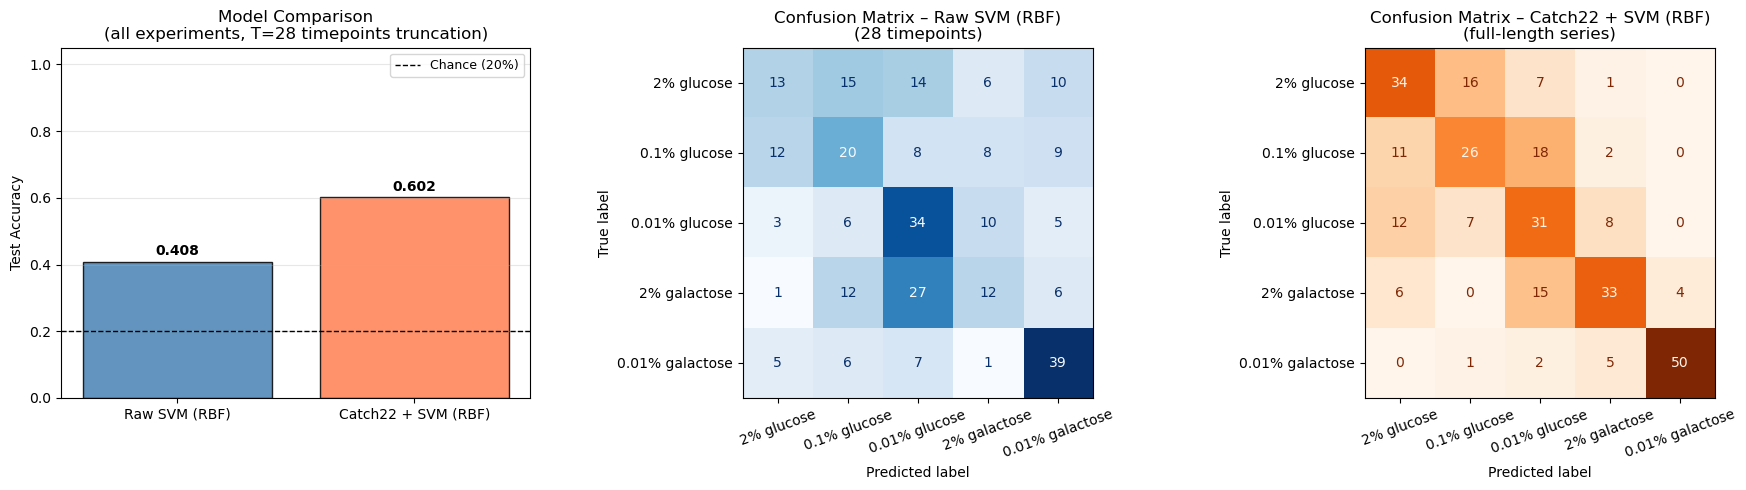


=== Summary ===
  Experiments: ['18446', '18589', '19316', '19330', '19391', '19392', '19394', '19554', '19566', '20213']
  Truncated to 28 timepoints for Raw SVM (global minimum)
  Raw SVM (RBF)       : 0.4083
  Catch22 + SVM (RBF) : 0.6021
  Winner: Catch22 + SVM (+0.1938)


In [14]:
class_names = [label_names[i] for i in sorted(label_names)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Accuracy bar chart ---
models  = ["Raw SVM (RBF)", "Catch22 + SVM (RBF)"]
accs    = [svm_acc, c22_acc]
colors  = ["steelblue", "coral"]

bars = axes[0].bar(models, accs, color=colors, alpha=0.85, edgecolor="black")
axes[0].axhline(1/len(label_names), color="black", linestyle="--", linewidth=1.0, label=f"Chance ({1/len(label_names):.0%})")
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Test Accuracy")
axes[0].set_title(f"Model Comparison\n(all experiments, T={X_train.shape[1]} timepoints truncation)")
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend(fontsize=9)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f"{acc:.3f}", ha="center", va="bottom", fontweight="bold")

# --- Confusion matrix: Raw SVM ---
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svm,
    display_labels=class_names,
    ax=axes[1],
    colorbar=False,
    cmap="Blues",
)
axes[1].set_title(f"Confusion Matrix – Raw SVM (RBF)\n({X_train.shape[1]} timepoints)")
axes[1].tick_params(axis="x", rotation=20)

# --- Confusion matrix: Catch22 + SVM ---
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_c22,
    display_labels=class_names,
    ax=axes[2],
    colorbar=False,
    cmap="Oranges",
)
axes[2].set_title("Confusion Matrix – Catch22 + SVM (RBF)\n(full-length series)")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("IY021_svm_vs_catch22_all_exp_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Summary ===")
print(f"  Experiments: {sorted(EXPERIMENT_LABELS.keys())}")
print(f"  Truncated to {X_train.shape[1]} timepoints for Raw SVM (global minimum)")
print(f"  Raw SVM (RBF)       : {svm_acc:.4f}")
print(f"  Catch22 + SVM (RBF) : {c22_acc:.4f}")
winner = "Raw SVM" if svm_acc >= c22_acc else "Catch22 + SVM"
print(f"  Winner: {winner} (+{abs(svm_acc - c22_acc):.4f})")